# Verificación de locutor de texto dependiente

Proyecto de Biometría de la Voz. El objetivo es construir un sistema que,
dado un audio de una persona diciendo un PIN, sea capaz de:

1. **Identificar al locutor** — ¿quién está hablando? (Red 1)
2. **Verificar la frase** — ¿ha dicho el PIN correcto? (Red 2)

Este notebook es el *orquestador*: no contiene la lógica interna, solo
llama en orden a las funciones de los módulos `src/data.py`,
`src/model.py` y `src/train.py`, y muestra los resultados.

## Base de datos

Usamos `PIN_16kHz`: 24 locutores que pronuncian PINs de 4 dígitos.
Tras la exploración (fase previa) sabemos que hay **2658 audios válidos**,
**40 clases de PIN** distintas, y descartamos 222 audios marcados como
defectuosos `(def)`, que se reservan para pruebas de robustez.

## 1. Preparación del entorno y carga de datos

Importamos los módulos del proyecto. La línea `sys.path.append("src")`
le dice a Python que busque también en la carpeta `src/`, que es donde
están nuestros módulos.

A continuación cargamos el dataset. Procesar los 2658 audios (leer cada
WAV y extraer sus MFCC) tarda un par de minutos, así que usamos una
**caché**: la primera vez se procesa todo y se guarda en un fichero
`cache_dataset.npz`; las siguientes veces se carga directamente de ahí,
en segundos.

procedemos a entrenar

In [1]:
import sys, os
sys.path.append("src")

import numpy as np
import data, model, train

CACHE = "cache_dataset.npz"

if os.path.exists(CACHE):
    # La caché ya existe: cargamos de disco (rápido)
    d = np.load(CACHE, allow_pickle=True)
    X, y_loc, y_pin = d["X"], d["y_loc"], d["y_pin"]
    mapas = d["mapas"].item()
    registros = d["registros"].tolist()      # <-- recuperamos los registros
    print("Dataset cargado de la caché:", X.shape)
else:
    # Primera vez: procesamos los audios y guardamos la caché
    registros = data.construir_indice()
    X, y_loc, y_pin, mapas = data.construir_dataset(registros)
    np.savez(CACHE, X=X, y_loc=y_loc, y_pin=y_pin,
             mapas=mapas, registros=registros)   # <-- guardamos registros
    print("Dataset procesado y guardado en caché:", X.shape)

2026-05-19 19:34:12.618125: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-19 19:34:12.672535: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-19 19:34:12.688435: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-19 19:34:12.794290: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Dataset cargado de la caché: (2658, 120, 63, 1)


## 2. Red 1 — Identificación del locutor

La primera red responde a la pregunta *"¿quién está hablando?"*. Es una
**CNN** (red convolucional) con **24 salidas**, una por cada locutor de
la base de datos.

### División de los datos

Antes de entrenar, dividimos los 2658 audios en tres grupos:

- **Train (70%)**: la red aprende con ellos.
- **Validación (15%)**: vigilamos el entrenamiento sin que la red aprenda
  de ellos; sirve para detectar sobreajuste.
- **Test (15%)**: no se tocan hasta el final; dan la medida honesta del
  rendimiento.

La división es *estratificada*: cada locutor aparece en los tres grupos
en la misma proporción.

In [2]:
# Dividimos los REGISTROS (rutas de fichero), no los MFCC.
# Esto nos permite saber qué audios están en train para poder
# aumentarlos después, antes de extraer sus MFCC.
reg_train, reg_val, reg_test = data.dividir_registros(registros)

Registros divididos -> train: 1860  |  val: 399  |  test: 399


### Aumento de datos (solo en train)

Para combatir el sobreajuste, generamos variaciones artificiales de los
audios de entrenamiento (ruido, desplazamiento temporal, cambio de
velocidad). Por cada audio original se crean 2 copias aumentadas, así
la red ve el triple de ejemplos y se ve forzada a generalizar.

**El aumento se aplica solo a train.** Validación y test se procesan sin
aumento, para que midan el rendimiento sobre audios reales.

In [3]:
# Train CON aumento (1860 originales + 2 copias cada uno = 5580)
print("Construyendo train (con aumento)...")
Xtr, ytr, ytr_pin = data.construir_dataset_desde_registros(
    reg_train, mapas, aumentar=True, n_aug=2)

# Validación y test SIN aumento
print("\nConstruyendo validación...")
Xv, yv, yv_pin = data.construir_dataset_desde_registros(
    reg_val, mapas, aumentar=False)

print("\nConstruyendo test...")
Xte, yte, yte_pin = data.construir_dataset_desde_registros(
    reg_test, mapas, aumentar=False)

print(f"\nTrain: {Xtr.shape}  |  Val: {Xv.shape}  |  Test: {Xte.shape}")

Construyendo train (con aumento)...
  Procesando audio 0/1860...
  Procesando audio 250/1860...
  Procesando audio 500/1860...
  Procesando audio 750/1860...
  Procesando audio 1000/1860...
  Procesando audio 1250/1860...
  Procesando audio 1500/1860...
  Procesando audio 1750/1860...
  Construido: (5580, 120, 63, 1) (con aumento x2)

Construyendo validación...
  Procesando audio 0/399...
  Procesando audio 250/399...
  Construido: (399, 120, 63, 1)

Construyendo test...
  Procesando audio 0/399...
  Procesando audio 250/399...
  Construido: (399, 120, 63, 1)

Train: (5580, 120, 63, 1)  |  Val: (399, 120, 63, 1)  |  Test: (399, 120, 63, 1)


### Creación y entrenamiento del modelo

Creamos la CNN con `model.construir_modelo`. Le pasamos:
- `"cnn"`: el tipo de arquitectura (la otra opción es `"cnn_lstm"`).
- `input_shape`: la forma de cada audio (nº de características × tiempo).
- `n_clases=24`: una salida por locutor.

Después la entrenamos. Cada *época* es una pasada completa por los datos
de train. El entrenamiento se detiene solo (EarlyStopping) cuando la red
deja de mejorar en validación.

In [5]:
# Creamos la CNN de 24 clases (una por locutor)
red1 = model.construir_modelo("cnn", input_shape=X.shape[1:], n_clases=24)

# La entrenamos. Guardará la mejor versión en resultados/red1_locutor.keras
hist1 = train.entrenar(red1, Xtr, ytr, Xv, yv,
                       ruta_modelo="resultados/red1_locutor.keras")

I0000 00:00:1779219367.116424    2074 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779219367.194311    2074 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779219367.195576    2074 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1779219367.198396    2074 cuda_executor.cc:1015] successful NUMA node read from SysFS ha


Entrenando 'CNN'...
  Train: 5580  |  Val: 399
  Batch: 32  |  Épocas máx: 60

Epoch 1/60


2026-05-19 19:36:07.795986: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 168739200 exceeds 10% of free system memory.
I0000 00:00:1779219369.617261    2174 service.cc:146] XLA service 0x798748013480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779219369.617312    2174 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6
2026-05-19 19:36:09.694921: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-05-19 19:36:09.973128: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8906
2026-05-19 19:36:11.357835: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2257', 32 bytes spill stores, 32 bytes spill loads

2026

  5/175 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.0686 - loss: 3.2090 

I0000 00:00:1779219377.545908    2174 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/175 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - accuracy: 0.1255 - loss: 2.9077 - val_accuracy: 0.0777 - val_loss: 4.7334
Epoch 2/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.2936 - loss: 2.0928 - val_accuracy: 0.1779 - val_loss: 3.2042
Epoch 3/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.3870 - loss: 1.7649 - val_accuracy: 0.2055 - val_loss: 2.9212
Epoch 4/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.4687 - loss: 1.5450 - val_accuracy: 0.4887 - val_loss: 1.5295
Epoch 5/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5204 - loss: 1.4012 - val_accuracy: 0.1805 - val_loss: 2.8623
Epoch 6/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.5782 - loss: 1.2477 - val_accuracy: 0.4411 - val_loss: 1.4511
Epoch 7/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6284 - loss: 1.1494 - val_accuracy: 0.3208 - val_loss: 2.1466
Epoch 8/60
175/175 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.6456 - loss: 1.0732 - val_accuracy: 0.44

### Evaluación de la Red 1

Entrenada la red, la evaluamos sobre el conjunto de **test** — los audios
que la red no ha visto nunca. El resultado en test es la medida honesta
de su rendimiento.

Generamos dos figuras:

- **Curvas de entrenamiento**: accuracy y pérdida a lo largo de las
  épocas, comparando train y validación. Si las curvas de train y
  validación se separan mucho, hay sobreajuste.
- **Matriz de confusión**: tabla que muestra, para cada locutor real,
  qué locutor predijo la red. La diagonal son los aciertos; lo de fuera,
  los errores.

In [6]:
# Lista de nombres de locutor, ordenada igual que las etiquetas
nombres_loc = sorted(mapas["locutor"].keys())

# Evaluamos sobre el conjunto de test
res1 = train.evaluar(red1, Xte, yte, nombres_clases=nombres_loc)


=== Evaluación en TEST ===
  Pérdida  : 0.3078
  Accuracy : 93.73%

              precision    recall  f1-score   support

         093       1.00      1.00      1.00        14
         147       1.00      0.94      0.97        18
         291       1.00      0.55      0.71        11
         379       0.86      1.00      0.92        18
         527       0.94      1.00      0.97        17
         544       1.00      0.89      0.94        18
         626       0.94      1.00      0.97        16
         639       0.94      1.00      0.97        17
         774       1.00      1.00      1.00        18
         785       1.00      0.94      0.97        17
         920       0.89      1.00      0.94        17
         a77       1.00      0.94      0.97        17
         b48       1.00      0.61      0.76        18
         b73       0.78      1.00      0.88        18
         c09       1.00      0.94      0.97        17
         c70       1.00      0.88      0.93        16
         d42

#### Figuras

Curvas guardadas en resultados/red1_curvas_aug.png


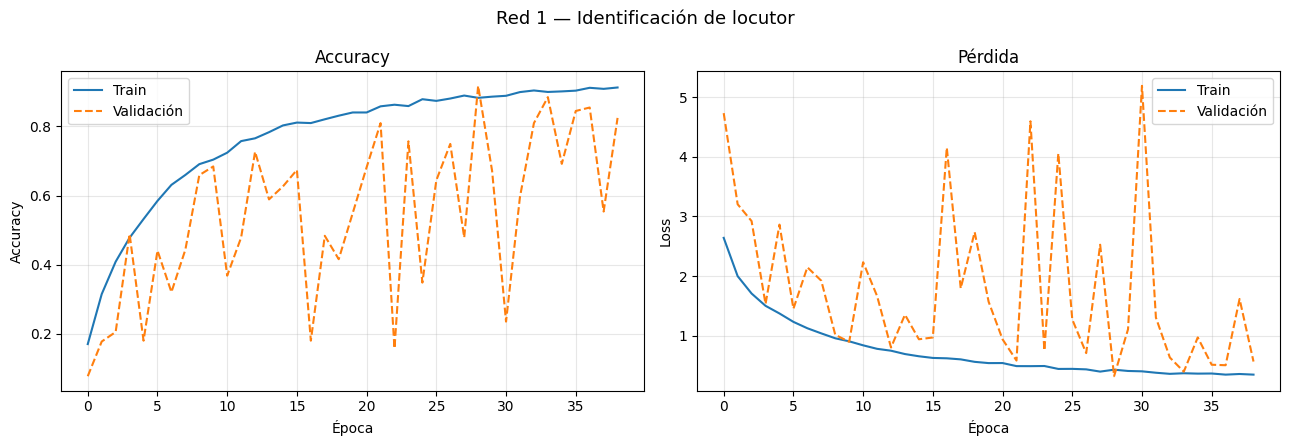

Matriz guardada en resultados/red1_matriz_aug.png


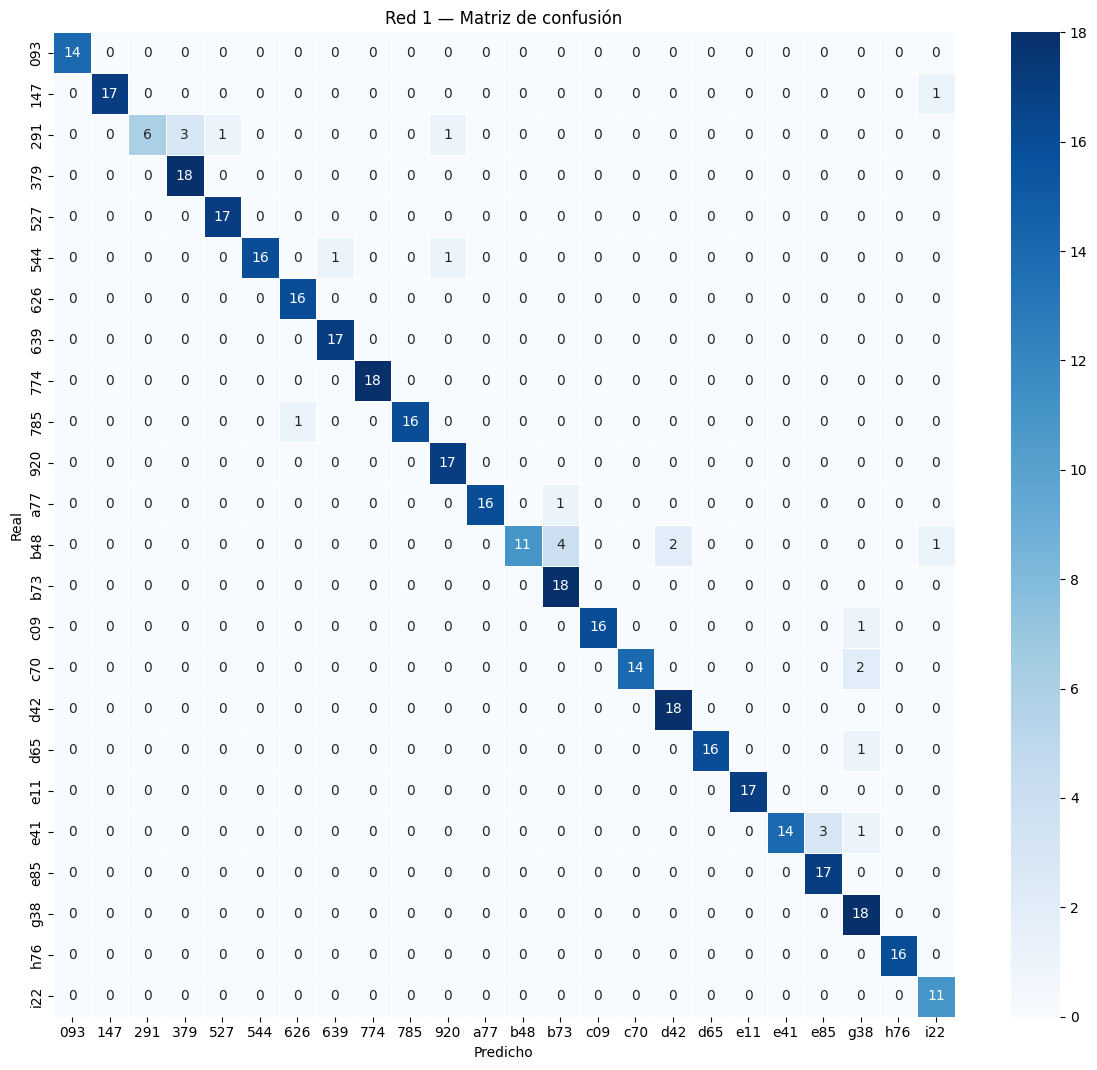

In [7]:
# Curvas de entrenamiento
train.graficar_entrenamiento(
    hist1,
    titulo="Red 1 — Identificación de locutor",
    guardar="resultados/red1_curvas_aug.png",
)

# Matriz de confusión
train.graficar_matriz_confusion(
    res1, nombres_loc,
    titulo="Red 1 — Matriz de confusión",
    guardar="resultados/red1_matriz_aug.png",
)

### Evaluación de la Red 1 (con aumento de datos)

Evaluamos el modelo mejorado y generamos las figuras. Comparamos con el
resultado sin aumento (82% en test) para cuantificar la mejora.

La matriz de confusión nos permitirá ver *con qué otros locutores* se
confunde el locutor 291, que es el que peor rinde (recall 0.27).

## 3. Red 2 — Verificación del PIN

La segunda red responde a la pregunta *"¿qué PIN se ha dicho?"*. Es una
**CNN** con **40 salidas**, una por cada PIN distinto de la base de datos.

Reutilizamos los mismos audios que en la Red 1: la diferencia está en la
etiqueta. Donde la Red 1 usaba la etiqueta de locutor, la Red 2 usa la
etiqueta de PIN.

### División de los datos

Volvemos a dividir los registros en train / val / test, pero esta vez
**estratificando por PIN**: cada PIN debe aparecer proporcionalmente en
los tres grupos.

In [8]:
# Dividimos los registros estratificando por PIN (campo="pin")
reg_train2, reg_val2, reg_test2 = data.dividir_registros(registros, campo="pin")

Registros divididos -> train: 1860  |  val: 399  |  test: 399
